In [1]:
!pip install -U "huggingface_hub[hf_xet]"

In [2]:
from pathlib import Path
from huggingface_hub import snapshot_download

out_dir = Path("data/pubtables-1m")

# Chọn subset muốn tải.
# Structure recognition: khoảng 32 GB+
allow_patterns = [
    "README.md",
    "extract_structure_dataset.sh",
    "PubTables-1M-Structure_*.tar.gz",
]

# Nếu muốn tải full 117 GB thì đổi thành:
# allow_patterns = ["*.tar.gz", "README.md", "extract_structure_dataset.sh"]

snapshot_download(
    repo_id="bsmock/pubtables-1m",
    repo_type="dataset",
    local_dir=str(out_dir),
    allow_patterns=allow_patterns,
    max_workers=8,
)

print(f"Downloaded to: {out_dir.resolve()}")

/media/drive-2t/miniconda3/envs/test_hoangnv83/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 10 files: 100%|██████████| 10/10 [16:59<00:00, 101.98s/it]

Downloaded to: /media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m


In [1]:
%cd "data/pubtables-1m"

/media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m


In [3]:
!mkdir -p PubTables-1M-Structure_Annotations_Test
!mkdir -p PubTables-1M-Structure_Annotations_Train
!mkdir -p PubTables-1M-Structure_Annotations_Val
!mkdir -p PubTables-1M-Structure_Images_Test
!mkdir -p PubTables-1M-Structure_Images_Train
!mkdir -p PubTables-1M-Structure_Images_Val
!mkdir -p PubTables-1M-Structure_Filelists
!mkdir -p PubTables-1M-Structure_Table_Words

!tar -xzf PubTables-1M-Structure_Annotations_Test.tar.gz -C PubTables-1M-Structure_Annotations_Test
!tar -xzf PubTables-1M-Structure_Annotations_Train.tar.gz -C PubTables-1M-Structure_Annotations_Train
!tar -xzf PubTables-1M-Structure_Annotations_Val.tar.gz -C PubTables-1M-Structure_Annotations_Val
!tar -xzf PubTables-1M-Structure_Images_Test.tar.gz -C PubTables-1M-Structure_Images_Test
!tar -xzf PubTables-1M-Structure_Images_Train.tar.gz -C PubTables-1M-Structure_Images_Train
!tar -xzf PubTables-1M-Structure_Images_Val.tar.gz -C PubTables-1M-Structure_Images_Val
!tar -xzf PubTables-1M-Structure_Filelists.tar.gz -C PubTables-1M-Structure_Filelists
!tar -xzf PubTables-1M-Structure_Table_Words.tar.gz -C PubTables-1M-Structure_Table_Words

In [2]:


import xml.etree.ElementTree as ET
from pathlib import Path 
from PIL import Image, ImageDraw, ImageFont


def parse_xml(xml_path: Path) -> dict:
    root = ET.parse(xml_path).getroot()
    filename = root.findtext("filename")
    width = int(float(root.findtext("size/width", "0")))
    height = int(float(root.findtext("size/height", "0")))

    objects = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        if bbox is None:
            continue
        objects.append(
            {
                "label": obj.findtext("name", ""),
                "bbox": [
                    float(bbox.findtext("xmin", "0")),
                    float(bbox.findtext("ymin", "0")),
                    float(bbox.findtext("xmax", "0")),
                    float(bbox.findtext("ymax", "0")),
                ],
            }
        )

    return {"filename": filename, "width": width, "height": height, "objects": objects}



def draw_labels(image_path: Path, objects: list[dict], keep_labels: set[str] | None = None):
    from PIL import Image, ImageDraw, ImageFont

    colors = {
        "table": "#ff3b30",
        "table row": "#34c759",
        "table column": "#007aff",
        "table column header": "#ff9500",
        "table projected row header": "#af52de",
        "table spanning cell": "#ff0000",  # đỏ
    }

    image = Image.open(image_path).convert("RGBA")
    overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    font = ImageFont.load_default()

    for obj in objects:
        label = obj["label"]
        if keep_labels and label not in keep_labels:
            continue

        x1, y1, x2, y2 = obj["bbox"]

        if label == "table spanning cell":
            # tô nền đỏ trong suốt + viền đỏ
            draw.rectangle((x1, y1, x2, y2), fill=(255, 0, 0, 60), outline=(255, 0, 0, 255), width=3)
            draw.text((x1 + 2, max(0, y1 - 12)), label, fill=(255, 0, 0, 255), font=font)
        else:
            color = colors.get(label, "#ffcc00")
            draw.rectangle((x1, y1, x2, y2), outline=color, width=2)
            draw.text((x1 + 2, max(0, y1 - 12)), label, fill=color, font=font)

    image = Image.alpha_composite(image, overlay).convert("RGB")
    return image

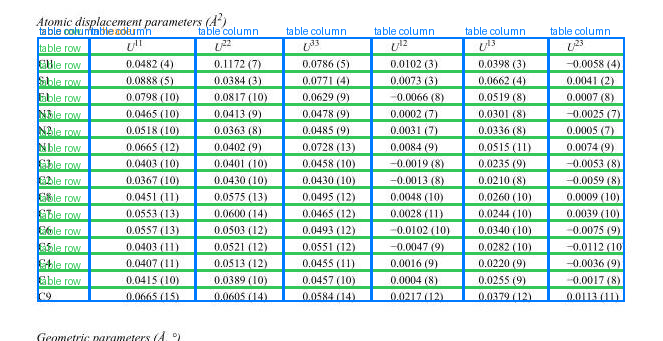

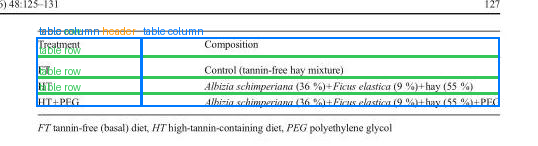

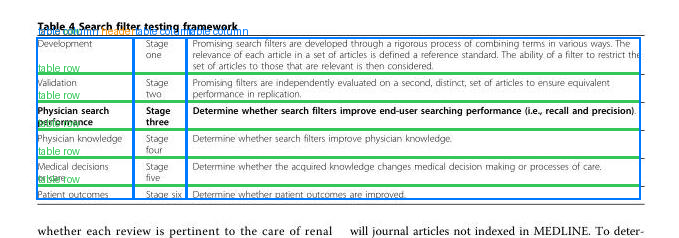

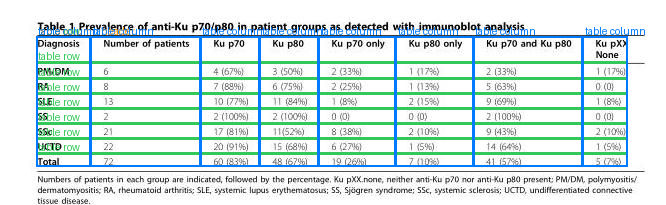

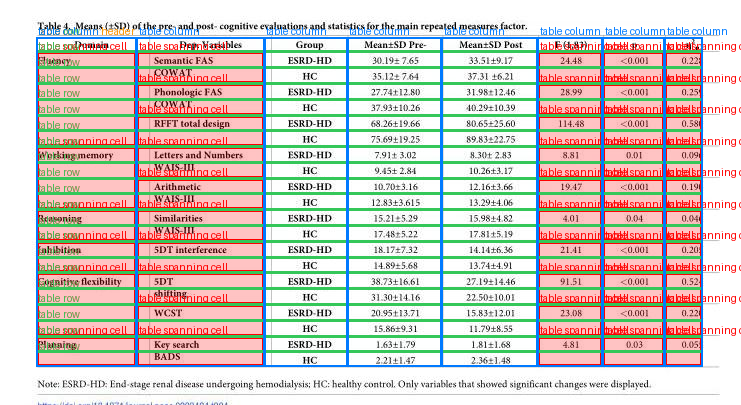

In [3]:
import os
labels = os.listdir("PubTables-1M-Structure_Annotations_Train")
for idx, label in enumerate(labels):
    lb = parse_xml(Path(f"PubTables-1M-Structure_Annotations_Train/{label}"))
    image = draw_labels(Path(f"PubTables-1M-Structure_Images_Train/{lb['filename']}"), lb["objects"]) 
    display(image)
    if idx==4:
        break

## PubTables-1M Structure EDA

Focused EDA for table statistics, span patterns, estimated empty cells, OCR/layout quality, and split summaries.


In [4]:
from __future__ import annotations

import json
import math
import re
import statistics
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "PubTables-1M-Structure_Filelists").exists():
    ROOT_DIR = Path("/media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m")

SPLITS = ["train", "val", "test"]

# XML stats are relatively cheap. None = scan all XML files.
MAX_XML_PER_SPLIT = None

# Words JSON is much slower because it reads many small files.
# Use 2000 for fast EDA, or None to estimate empty cells/OCR quality for all tables.
MAX_WORD_FILES_PER_SPLIT = 2000
RANDOM_SEED = 42

print("ROOT_DIR =", ROOT_DIR)


ROOT_DIR = /media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m


/media/drive-2t/miniconda3/envs/test_hoangnv83/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
LABELS = {
    "table",
    "table row",
    "table column",
    "table column header",
    "table projected row header",
    "table spanning cell",
}
SOURCE_RE = re.compile(r"^(?P<source_id>PMC\d+)_table_(?P<table_index>\d+)$")


def split_to_title(split: str) -> str:
    return "Val" if split == "val" else split.title()


def safe_float(text, default=0.0) -> float:
    try:
        return float(text)
    except (TypeError, ValueError):
        return default


def overlap_1d(a1, a2, b1, b2) -> float:
    return max(0.0, min(a2, b2) - max(a1, b1))


def coefficient_of_variation(values) -> float:
    values = [v for v in values if v > 0]
    if len(values) < 2:
        return 0.0
    mean = statistics.fmean(values)
    return 0.0 if mean == 0 else statistics.pstdev(values) / mean


def parse_source(filename: str):
    stem = Path(filename).stem
    match = SOURCE_RE.match(stem)
    if not match:
        return stem, -1
    return match.group("source_id"), int(match.group("table_index"))


def xml_paths_for_split(split: str):
    filelist_path = ROOT_DIR / "PubTables-1M-Structure_Filelists" / f"{split}_filelist.txt"
    ann_dir = ROOT_DIR / f"PubTables-1M-Structure_Annotations_{split_to_title(split)}"

    if filelist_path.exists():
        paths = [ann_dir / Path(row.strip()).name for row in filelist_path.read_text().splitlines() if row.strip()]
    else:
        paths = sorted(ann_dir.glob("*.xml"))

    if MAX_XML_PER_SPLIT is not None:
        paths = paths[:MAX_XML_PER_SPLIT]
    return paths


In [6]:
def parse_pubtables_xml(xml_path: Path, split: str) -> dict:
    root = ET.parse(xml_path).getroot()
    filename = root.findtext("filename") or f"{xml_path.stem}.jpg"
    width = int(safe_float(root.findtext("size/width")))
    height = int(safe_float(root.findtext("size/height")))

    label_counts = Counter()
    table_bbox = None
    row_bboxes = []
    column_bboxes = []
    spanning_bboxes = []
    all_bboxes = []

    for obj in root.findall("object"):
        label = obj.findtext("name", "")
        bbox_node = obj.find("bndbox")
        if label not in LABELS or bbox_node is None:
            continue

        bbox = [
            safe_float(bbox_node.findtext("xmin")),
            safe_float(bbox_node.findtext("ymin")),
            safe_float(bbox_node.findtext("xmax")),
            safe_float(bbox_node.findtext("ymax")),
        ]
        label_counts[label] += 1
        all_bboxes.append(bbox)

        if label == "table":
            table_bbox = bbox
        elif label == "table row":
            row_bboxes.append(bbox)
        elif label == "table column":
            column_bboxes.append(bbox)
        elif label == "table spanning cell":
            spanning_bboxes.append(bbox)

    if table_bbox is None and all_bboxes:
        xs1, ys1, xs2, ys2 = zip(*all_bboxes)
        table_bbox = [min(xs1), min(ys1), max(xs2), max(ys2)]
    if table_bbox is None:
        table_bbox = [0.0, 0.0, 0.0, 0.0]

    span_patterns = []
    span_extra_slots = 0
    max_rowspan = 1
    max_colspan = 1

    for sb in spanning_bboxes:
        sx1, sy1, sx2, sy2 = sb
        sw = max(1e-6, sx2 - sx1)
        sh = max(1e-6, sy2 - sy1)

        rowspan = sum(
            overlap_1d(sy1, sy2, rb[1], rb[3]) / min(sh, max(1e-6, rb[3] - rb[1])) >= 0.5
            for rb in row_bboxes
        )
        colspan = sum(
            overlap_1d(sx1, sx2, cb[0], cb[2]) / min(sw, max(1e-6, cb[2] - cb[0])) >= 0.5
            for cb in column_bboxes
        )
        rowspan = max(1, rowspan)
        colspan = max(1, colspan)
        max_rowspan = max(max_rowspan, rowspan)
        max_colspan = max(max_colspan, colspan)
        span_extra_slots += rowspan * colspan - 1
        span_patterns.append(f"r{rowspan}c{colspan}")

    num_rows = label_counts["table row"]
    num_columns = label_counts["table column"]
    grid_cells = num_rows * num_columns
    table_w = max(0.0, table_bbox[2] - table_bbox[0])
    table_h = max(0.0, table_bbox[3] - table_bbox[1])
    image_area = width * height
    source_id, table_index = parse_source(filename)

    return {
        "record_id": xml_path.stem,
        "source_id": source_id,
        "table_index": table_index,
        "split": split,
        "filename": filename,
        "xml_path": str(xml_path),
        "image_path": str(ROOT_DIR / f"PubTables-1M-Structure_Images_{split_to_title(split)}" / filename),
        "words_path": str(ROOT_DIR / "PubTables-1M-Structure_Table_Words" / f"{xml_path.stem}_words.json"),
        "width": width,
        "height": height,
        "num_rows": num_rows,
        "num_columns": num_columns,
        "grid_cells": grid_cells,
        "num_merged_cells": label_counts["table spanning cell"],
        "max_rowspan": max_rowspan,
        "max_colspan": max_colspan,
        "span_extra_slots": span_extra_slots,
        "span_patterns": "|".join(span_patterns),
        "table_area_ratio": (table_w * table_h / image_area) if image_area else 0.0,
        "aspect_ratio": table_w / table_h if table_h else 0.0,
        "row_height_cv": coefficient_of_variation([b[3] - b[1] for b in row_bboxes]),
        "column_width_cv": coefficient_of_variation([b[2] - b[0] for b in column_bboxes]),
        "table_bbox": table_bbox,
        "row_bboxes": row_bboxes,
        "column_bboxes": column_bboxes,
    }


In [7]:
records = []

for split in SPLITS:
    paths = xml_paths_for_split(split)
    print(f"{split}: scanning {len(paths):,} XML files")
    for xml_path in tqdm(paths, desc=f"parse {split}"):
        if xml_path.exists():
            records.append(parse_pubtables_xml(xml_path, split))

stats_df = pd.DataFrame(records)
print("stats_df:", stats_df.shape)
stats_df.head()


train: scanning 758,849 XML files


parse train:   4%|▍         | 32494/758849 [00:18<06:22, 1899.28it/s]

parse train: 100%|██████████| 758849/758849 [07:08<00:00, 1772.10it/s]


val: scanning 94,959 XML files


parse val: 100%|██████████| 94959/94959 [02:08<00:00, 738.14it/s] 


test: scanning 93,834 XML files


parse test: 100%|██████████| 93834/93834 [00:53<00:00, 1764.31it/s]


stats_df: (947642, 25)


,record_id,source_id,table_index,split,filename,xml_path,image_path,words_path,width,height,...,max_colspan,span_extra_slots,span_patterns,table_area_ratio,aspect_ratio,row_height_cv,column_width_cv,table_bbox,row_bboxes,column_bboxes
0,PMC5070146_table_0,PMC5070146,0,train,PMC5070146_table_0.jpg,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,685,209,...,2,13,r1c2|r1c2|r6c1|r1c2|r1c2|r1c2|r1c2|r1c2|r1c2,0.565950,4.582683,0.092496,0.134076,"[36.687, 37.3821, 646.0377, 170.3502]","[[36.687, 37.3821, 646.0377, 51.2958], [36.687...","[[36.687, 37.3821, 151.3743, 170.3502], [151.3..."
1,PMC4352559_table_0,PMC4352559,0,train,PMC4352559_table_0.jpg,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,682,527,...,1,0,,0.762506,1.345168,0.047642,0.147577,"[36.4304, 37.2232, 643.5965, 488.5914]","[[36.4304, 37.2232, 643.5965, 51.2288], [36.43...","[[36.4304, 37.2232, 204.5687, 488.5914], [204...."
2,PMC2816221_table_3,PMC2816221,3,train,PMC2816221_table_3.jpg,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,690,562,...,1,0,,0.769143,1.263045,0.043984,0.242738,"[37.0021, 36.9932, 650.7722, 522.938]","[[37.0021, 36.9932, 650.7722, 52.482], [37.002...","[[37.0021, 36.9932, 213.4899, 522.938], [213.4..."
3,PMC3201275_table_2,PMC3201275,2,train,PMC3201275_table_2.jpg,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,564,268,...,1,0,,0.623310,2.527563,0.303790,0.256046,"[37.0781, 36.2997, 525.0669, 229.3666]","[[37.0781, 36.2997, 525.0669, 64.4904], [37.07...","[[37.0781, 36.2997, 218.5986, 229.3666], [218...."
4,PMC4502840_table_2,PMC4502840,2,train,PMC4502840_table_2.jpg,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,653,184,...,1,0,,0.548110,5.135001,0.061581,0.320516,"[34.5049, 34.5712, 616.0314, 147.8188]","[[34.5049, 34.5712, 616.0314, 46.3868], [34.50...","[[34.5049, 34.5712, 140.3272, 147.8188], [140...."


In [15]:
# Count tables, rows, columns, merged cells, and split-level characteristics.
split_summary = (
    stats_df.groupby("split")
    .agg(
        tables=("record_id", "count"),
        total_rows=("num_rows", "sum"),
        total_columns=("num_columns", "sum"),
        rows_mean=("num_rows", "mean"),
        rows_median=("num_rows", "median"),
        rows_max=("num_rows", "max"),
        columns_mean=("num_columns", "mean"),
        columns_median=("num_columns", "median"),
        columns_max=("num_columns", "max"),
        grid_cells_mean=("grid_cells", "mean"),
        grid_cells_median=("grid_cells", "median"),
        grid_cells_max=("grid_cells", "max"),
        merged_cells_sum=("num_merged_cells", "sum"),
        tables_with_merged_cells=("num_merged_cells", lambda s: int((s > 0).sum())),
        max_rowspan=("max_rowspan", "max"),
        max_colspan=("max_colspan", "max"),
        span_extra_slots_sum=("span_extra_slots", "sum"),
    )
    .reset_index()
)

split_summary


,split,tables,total_rows,total_columns,rows_mean,rows_median,rows_max,columns_mean,columns_median,columns_max,grid_cells_mean,grid_cells_median,grid_cells_max,merged_cells_sum,tables_with_merged_cells,max_rowspan,max_colspan,span_extra_slots_sum
0,test,93834,1255017,514253,13.374864,10.0,74,5.480455,5.0,51,75.039719,52.0,1326,204428,39400,52,25,366046
1,train,758849,10181168,4141287,13.416593,10.0,85,5.457327,5.0,52,74.884211,52.0,1560,1659055,317572,55,40,2950634
2,val,94959,1270392,517943,13.378321,10.0,71,5.454386,5.0,38,74.728820,52.0,1144,206693,39641,39,35,368044


In [16]:
# Table-size and cell-span distributions.
def table_size_bucket(grid_cells):
    if grid_cells <= 20:
        return "small"
    if grid_cells <= 80:
        return "medium"
    if grid_cells <= 120:
        return "large"
    return "very_large"

stats_df["table_size_bucket"] = stats_df["grid_cells"].map(table_size_bucket)

table_size_distribution = pd.crosstab(
    stats_df["split"],
    stats_df["table_size_bucket"],
    normalize="index",
).round(3)

size_describe = (
    stats_df.groupby("split")[["num_rows", "num_columns", "grid_cells", "num_merged_cells", "span_extra_slots"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

span_rows = []
for split, group in stats_df.groupby("split"):
    counter = Counter()
    for patterns in group["span_patterns"].fillna(""):
        for pattern in patterns.split("|"):
            if pattern:
                counter[pattern] += 1
    for pattern, count in counter.most_common():
        span_rows.append({"split": split, "span_pattern": pattern, "count": count})

span_pattern_distribution = pd.DataFrame(span_rows)

print("Table size distribution")
display(table_size_distribution)
print("Size/stat distributions")
display(size_describe)
print("Top span patterns per split")
display(span_pattern_distribution.groupby("split").head(20))


Table size distribution


table_size_bucket,large,medium,small,very_large
split,,,,
test,0.142,0.512,0.169,0.176
train,0.140,0.514,0.168,0.178
val,0.142,0.512,0.169,0.176


Size/stat distributions


num_rows                                                               \
          count       mean       std  min  25%   50%   75%   90%   95%   99%   
split                                                                          
test    93834.0  13.374864  9.357587  1.0  7.0  10.0  18.0  27.0  33.0  43.0   
train  758849.0  13.416593  9.348925  1.0  7.0  10.0  18.0  27.0  33.0  43.0   
val     94959.0  13.378321  9.269619  1.0  7.0  10.0  18.0  27.0  33.0  43.0   

       ... span_extra_slots                                                  \
       ...             mean       std  min  25%  50%  75%   90%   95%   99%   
split  ...                                                                    
test   ...         3.900995  8.179194  0.0  0.0  0.0  5.0  12.0  18.0  36.0   
train  ...         3.888302  8.036179  0.0  0.0  0.0  5.0  12.0  18.0  36.0   
val    ...         3.875820  7.974350  0.0  0.0  0.0  5.0  12.0  18.0  36.0   

              
         max  
split         
test   275.0  
train  428.0  
val    186.0  

[3 rows x 55 columns]

Top span patterns per split


,split,span_pattern,count
0,test,r2c1,95082
1,test,r1c2,39085
2,test,r3c1,20865
3,test,r1c3,14642
4,test,r4c1,8517
5,test,r1c4,6755
6,test,r5c1,3805
7,test,r1c5,2585
8,test,r6c1,2409
9,test,r1c6,1859


In [27]:
def estimate_empty_cells_and_word_quality(row) -> dict:
    words_path = Path(row["words_path"])
    if not words_path.exists():
        return {
            "words_available": False,
            "num_words": 0,
            "words_inside_table": 0,
            "words_outside_table": 0,
            "words_with_negative_bbox": 0,
            "empty_text_words": 0,
            "estimated_nonempty_cells": math.nan,
            "estimated_empty_cells": math.nan,
            "estimated_empty_cell_rate": math.nan,
            "word_inside_table_ratio": math.nan,
        }

    words = json.loads(words_path.read_text())
    tx1, ty1, tx2, ty2 = row["table_bbox"]
    row_bboxes = row["row_bboxes"]
    column_bboxes = row["column_bboxes"]
    occupied = set()

    words_inside = 0
    words_negative = 0
    empty_text_words = 0

    for word in words:
        bbox = word.get("bbox") or [0, 0, 0, 0]
        x1, y1, x2, y2 = bbox[:4]
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        if min(x1, y1, x2, y2) < 0:
            words_negative += 1
        if not str(word.get("text", "")).strip():
            empty_text_words += 1
        if tx1 <= cx <= tx2 and ty1 <= cy <= ty2:
            words_inside += 1

        row_idx = next((i for i, rb in enumerate(row_bboxes) if rb[1] <= cy <= rb[3]), None)
        col_idx = next((j for j, cb in enumerate(column_bboxes) if cb[0] <= cx <= cb[2]), None)
        if row_idx is not None and col_idx is not None:
            occupied.add((row_idx, col_idx))

    grid_cells = row["grid_cells"]
    estimated_nonempty = len(occupied)
    estimated_empty = max(0, grid_cells - estimated_nonempty) if grid_cells else math.nan

    return {
        "words_available": True,
        "num_words": len(words),
        "words_inside_table": words_inside,
        "words_outside_table": len(words) - words_inside,
        "words_with_negative_bbox": words_negative,
        "empty_text_words": empty_text_words,
        "estimated_nonempty_cells": estimated_nonempty,
        "estimated_empty_cells": estimated_empty,
        "estimated_empty_cell_rate": estimated_empty / grid_cells if grid_cells else math.nan,
        "word_inside_table_ratio": words_inside / len(words) if words else math.nan,
    }


def sample_for_words(df, split):
    part = df[df["split"] == split]
    if MAX_WORD_FILES_PER_SPLIT is None or len(part) <= MAX_WORD_FILES_PER_SPLIT:
        return part
    return part.sample(n=MAX_WORD_FILES_PER_SPLIT, random_state=RANDOM_SEED)

word_quality_rows = []
for split in SPLITS:
    sample_df = sample_for_words(stats_df, split)
    print(f"{split}: inspecting words/OCR for {len(sample_df):,} tables")
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc=f"words {split}"):
        quality = estimate_empty_cells_and_word_quality(row)
        quality.update({"record_id": row["record_id"], "split": split})
        word_quality_rows.append(quality)

word_quality_df = pd.DataFrame(word_quality_rows)
word_quality_df.head()


train: inspecting words/OCR for 2,000 tables


words train: 100%|██████████| 2000/2000 [00:02<00:00, 991.55it/s] 


val: inspecting words/OCR for 2,000 tables


words val: 100%|██████████| 2000/2000 [00:01<00:00, 1012.38it/s]


test: inspecting words/OCR for 2,000 tables


words test: 100%|██████████| 2000/2000 [00:01<00:00, 1036.93it/s]


,words_available,num_words,words_inside_table,words_outside_table,words_with_negative_bbox,empty_text_words,estimated_nonempty_cells,estimated_empty_cells,estimated_empty_cell_rate,word_inside_table_ratio,record_id,split
0,True,105,96,9,0,0,44,32,0.421053,0.914286,PMC4476782_table_0,train
1,True,73,69,4,0,0,34,21,0.381818,0.945205,PMC2655292_table_4,train
2,True,131,112,19,0,0,59,6,0.092308,0.854962,PMC4554319_table_1,train
3,True,31,17,14,0,0,16,4,0.200000,0.548387,PMC4591122_table_2,train
4,True,263,247,16,1,0,138,37,0.211429,0.939163,PMC6046463_table_0,train


In [28]:
# OCR/layout quality and estimated empty-cell summary.
word_quality_summary = (
    word_quality_df.groupby("split")
    .agg(
        inspected_tables=("record_id", "count"),
        words_available=("words_available", "sum"),
        mean_words=("num_words", "mean"),
        median_words=("num_words", "median"),
        estimated_empty_cells_sum=("estimated_empty_cells", "sum"),
        estimated_empty_cell_rate_mean=("estimated_empty_cell_rate", "mean"),
        estimated_empty_cell_rate_median=("estimated_empty_cell_rate", "median"),
        word_inside_table_ratio_mean=("word_inside_table_ratio", "mean"),
        words_outside_table_sum=("words_outside_table", "sum"),
        words_with_negative_bbox_sum=("words_with_negative_bbox", "sum"),
        empty_text_words_sum=("empty_text_words", "sum"),
    )
    .reset_index()
)

word_quality_summary


,split,inspected_tables,words_available,mean_words,median_words,estimated_empty_cells_sum,estimated_empty_cell_rate_mean,estimated_empty_cell_rate_median,word_inside_table_ratio_mean,words_outside_table_sum,words_with_negative_bbox_sum,empty_text_words_sum
0,test,2000,2000,145.9925,120.0,17639,0.096784,0.057143,0.748472,61221,4158,0
1,train,2000,2000,152.8365,124.0,21026,0.100716,0.062500,0.755369,61089,4085,5
2,val,2000,2000,146.6155,118.0,18999,0.096708,0.055556,0.750497,58841,3763,4


In [29]:
# Final split summary with estimated empty-cell columns when words were inspected.
eda_df = stats_df.merge(word_quality_df, on=["record_id", "split"], how="left")

final_split_summary = split_summary.merge(
    word_quality_summary,
    on="split",
    how="left",
)

final_split_summary


,split,tables,total_rows,total_columns,rows_mean,rows_median,rows_max,columns_mean,columns_median,columns_max,...,words_available,mean_words,median_words,estimated_empty_cells_sum,estimated_empty_cell_rate_mean,estimated_empty_cell_rate_median,word_inside_table_ratio_mean,words_outside_table_sum,words_with_negative_bbox_sum,empty_text_words_sum
0,test,93834,1255017,514253,13.374864,10.0,74,5.480455,5.0,51,...,2000,145.9925,120.0,17639,0.096784,0.057143,0.748472,61221,4158,0
1,train,758849,10181168,4141287,13.416593,10.0,85,5.457327,5.0,52,...,2000,152.8365,124.0,21026,0.100716,0.062500,0.755369,61089,4085,5
2,val,94959,1270392,517943,13.378321,10.0,71,5.454386,5.0,38,...,2000,146.6155,118.0,18999,0.096708,0.055556,0.750497,58841,3763,4


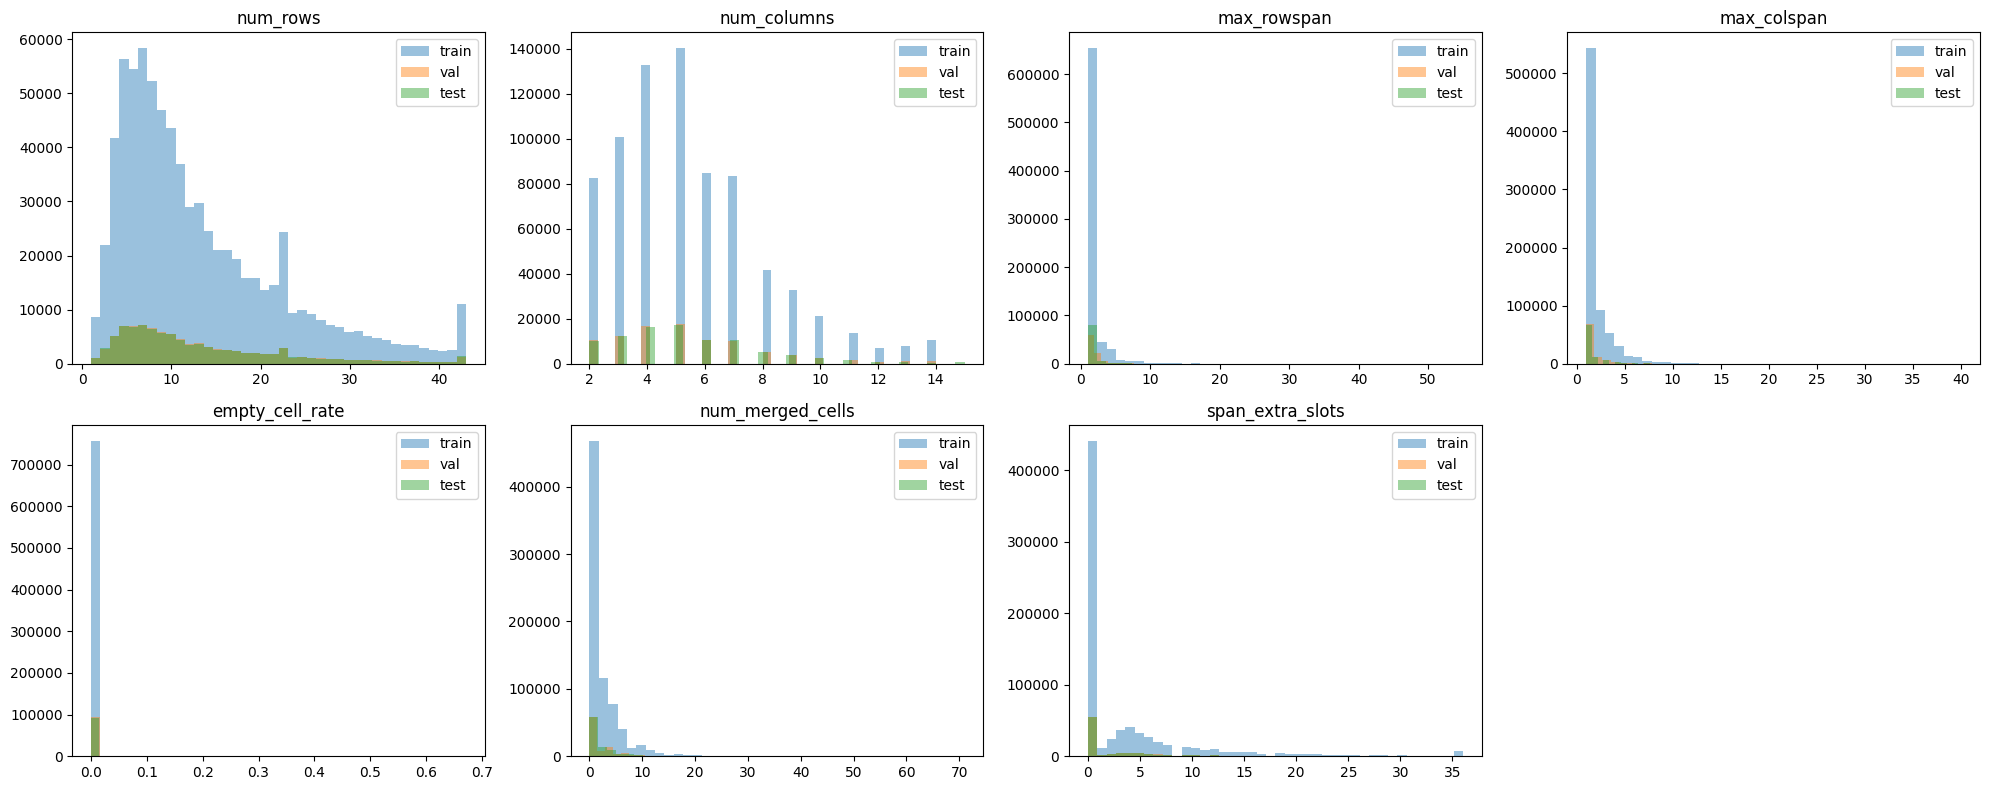

In [30]:
# Visualize only the selected EDA features.
plot_df = eda_df.copy()
plot_df["empty_cell_rate"] = plot_df["estimated_empty_cell_rate"].fillna(0.0)

plot_cols = [
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    for split in SPLITS:
        values = plot_df.loc[plot_df["split"] == split, col].dropna()
        if col in {"num_rows", "num_columns", "span_extra_slots"} and len(values) > 0:
            values = values.clip(upper=values.quantile(0.99))
        ax.hist(values, bins=40, alpha=0.45, label=split)
    ax.set_title(col)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


In [31]:
OUT_DIR = ROOT_DIR / "eda_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

stats_df.drop(columns=["table_bbox", "row_bboxes", "column_bboxes"]).to_csv(
    OUT_DIR / "pubtables_structure_stats.csv",
    index=False,
)
word_quality_df.to_csv(OUT_DIR / "pubtables_word_quality.csv", index=False)
split_summary.to_csv(OUT_DIR / "pubtables_split_summary.csv", index=False)
word_quality_summary.to_csv(OUT_DIR / "pubtables_word_quality_summary.csv", index=False)
span_pattern_distribution.to_csv(OUT_DIR / "pubtables_span_patterns.csv", index=False)
final_split_summary.to_csv(OUT_DIR / "pubtables_final_split_summary.csv", index=False)

print("Saved EDA outputs to:", OUT_DIR)


Saved EDA outputs to: /media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m/eda_outputs


## Difficulty Score và hard subset 200 ảnh

Mục tiêu: chọn 200 ảnh PubTables-1M khó để debug nhanh, giữ tỷ lệ split `train=70%`, `val=20%`, `test=10%`.

Các thông số dùng để định nghĩa độ khó:

- `num_rows`: số hàng của bảng. Bảng càng nhiều hàng càng khó nhận diện cấu trúc.
- `num_columns`: số cột của bảng. Bảng càng nhiều cột càng dễ lỗi tách cột hoặc gán text sai cột.
- `max_rowspan`: số hàng lớn nhất mà một ô spanning cell phủ qua. `1` nghĩa là không có merge dọc rõ ràng.
- `max_colspan`: số cột lớn nhất mà một ô spanning cell phủ qua. `1` nghĩa là không có merge ngang rõ ràng.
- `empty_cell_rate`: tỷ lệ ô rỗng ước lượng. Với PubTables, chỉ số này được ước lượng từ `Table_Words` bằng cách map word vào grid row/column.
- `num_merged_cells`: số ô spanning/merged cell trong XML, tương ứng label `table spanning cell`.
- `span_extra_slots`: tổng số grid slot bị chiếm thêm do spanning cells. Chỉ số này đo mức độ merge nặng nhẹ của toàn bảng.


In [23]:
# Build a compact sampling dataframe from the EDA outputs.
# PubTables has estimated empty cells only for rows inspected in word_quality_df.
# Missing estimated empty rate is filled with 0 so full-dataset structure sampling still works.

sample_df = eda_df.copy()

sample_df["empty_cell_rate"] = sample_df["estimated_empty_cell_rate"].fillna(0.0)
sample_df["num_merged_cells"] = sample_df["num_merged_cells"].fillna(0).astype(int)
sample_df["span_extra_slots"] = sample_df["span_extra_slots"].fillna(0).astype(int)
sample_df["max_rowspan"] = sample_df["max_rowspan"].fillna(1).astype(int)
sample_df["max_colspan"] = sample_df["max_colspan"].fillna(1).astype(int)

sample_df[[
    "split",
    "record_id",
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
]].head()


,split,record_id,num_rows,num_columns,max_rowspan,max_colspan,empty_cell_rate,num_merged_cells,span_extra_slots
0,train,PMC5070146_table_0,8,6,6,2,0.0,9,13
1,train,PMC4352559_table_0,26,4,1,1,0.0,0,0
2,train,PMC2816221_table_3,31,5,1,1,0.0,0,0
3,train,PMC3201275_table_2,8,2,1,1,0.0,0,0
4,train,PMC4502840_table_2,9,9,1,1,0.0,0,0


In [24]:
def level_num_rows(num_rows):
    if num_rows <= 5:
        return 0
    if num_rows <= 15:
        return 1
    if num_rows <= 30:
        return 2
    return 3


def level_num_columns(num_columns):
    if num_columns <= 4:
        return 0
    if num_columns <= 8:
        return 1
    if num_columns <= 12:
        return 2
    return 3


def level_rowspan(max_rowspan):
    if max_rowspan <= 1:
        return 0
    if max_rowspan == 2:
        return 1
    if max_rowspan <= 4:
        return 2
    return 3


def level_colspan(max_colspan):
    if max_colspan <= 1:
        return 0
    if max_colspan == 2:
        return 1
    if max_colspan <= 5:
        return 2
    return 3


def level_empty_cell_rate(empty_cell_rate):
    if empty_cell_rate <= 0:
        return 0
    if empty_cell_rate <= 0.10:
        return 1
    if empty_cell_rate <= 0.30:
        return 2
    return 3


def level_num_merged_cells(num_merged_cells):
    if num_merged_cells <= 0:
        return 0
    if num_merged_cells <= 2:
        return 1
    if num_merged_cells <= 5:
        return 2
    return 3


def level_span_extra_slots(span_extra_slots):
    if span_extra_slots <= 0:
        return 0
    if span_extra_slots <= 3:
        return 1
    if span_extra_slots <= 9:
        return 2
    return 3


def difficulty_flags(row):
    flags = []
    if level_num_rows(row["num_rows"]) >= 2:
        flags.append("many_rows")
    if level_num_columns(row["num_columns"]) >= 2:
        flags.append("many_columns")
    if level_rowspan(row["max_rowspan"]) >= 2:
        flags.append("large_rowspan")
    if level_colspan(row["max_colspan"]) >= 2:
        flags.append("large_colspan")
    if level_empty_cell_rate(row["empty_cell_rate"]) >= 2:
        flags.append("many_empty_cells")
    if level_num_merged_cells(row["num_merged_cells"]) >= 2:
        flags.append("many_merged_cells")
    if level_span_extra_slots(row["span_extra_slots"]) >= 2:
        flags.append("complex_span")
    return flags


def difficulty_score(row):
    # Weighted heuristic for sampling, not an official PubTables metric.
    return (
        1.0 * level_num_rows(row["num_rows"])
        + 1.0 * level_num_columns(row["num_columns"])
        + 1.5 * level_rowspan(row["max_rowspan"])
        + 1.5 * level_colspan(row["max_colspan"])
        + 1.0 * level_empty_cell_rate(row["empty_cell_rate"])
        + 1.5 * level_num_merged_cells(row["num_merged_cells"])
        + 1.5 * level_span_extra_slots(row["span_extra_slots"])
    )


def difficulty_level(score):
    if score < 6:
        return "easy"
    if score < 12:
        return "medium"
    if score < 18:
        return "hard"
    return "very_hard"


sample_df["row_level"] = sample_df["num_rows"].map(level_num_rows)
sample_df["column_level"] = sample_df["num_columns"].map(level_num_columns)
sample_df["rowspan_level"] = sample_df["max_rowspan"].map(level_rowspan)
sample_df["colspan_level"] = sample_df["max_colspan"].map(level_colspan)
sample_df["empty_level"] = sample_df["empty_cell_rate"].map(level_empty_cell_rate)
sample_df["merged_level"] = sample_df["num_merged_cells"].map(level_num_merged_cells)
sample_df["span_extra_level"] = sample_df["span_extra_slots"].map(level_span_extra_slots)
sample_df["difficulty_score"] = sample_df.apply(difficulty_score, axis=1)
sample_df["difficulty_level"] = sample_df["difficulty_score"].map(difficulty_level)
sample_df["difficulty_flags"] = sample_df.apply(lambda row: "|".join(difficulty_flags(row)), axis=1)
sample_df["num_difficulty_flags"] = sample_df["difficulty_flags"].map(lambda x: 0 if not x else len(x.split("|")))

sample_df[[
    "split",
    "record_id",
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
    "difficulty_score",
    "difficulty_level",
    "difficulty_flags",
]].sort_values("difficulty_score", ascending=False).head(20)


,split,record_id,num_rows,num_columns,max_rowspan,max_colspan,empty_cell_rate,num_merged_cells,span_extra_slots,difficulty_score,difficulty_level,difficulty_flags
782410,val,PMC2631514_table_2,45,13,9,10,0.117949,17,54,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...
347958,train,PMC1892772_table_3,22,22,7,7,0.431818,6,34,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...
814878,val,PMC5978836_table_2,21,14,6,9,0.108844,10,38,25.0,very_hard,many_rows|many_columns|large_rowspan|large_col...
925407,test,PMC2866322_table_2,20,18,18,3,0.308333,11,31,24.5,very_hard,many_rows|many_columns|large_rowspan|large_col...
408751,train,PMC6226170_table_0,30,14,4,7,0.333333,20,80,24.5,very_hard,many_rows|many_columns|large_rowspan|large_col...
838878,val,PMC5824959_table_2,33,11,3,9,0.325069,14,35,24.5,very_hard,many_rows|many_columns|large_rowspan|large_col...
871402,test,PMC2829004_table_5,32,10,6,4,0.325000,8,32,24.5,very_hard,many_rows|many_columns|large_rowspan|large_col...
463383,train,PMC4887112_table_0,32,13,6,6,0.000000,11,35,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...
682934,train,PMC2928743_table_3,33,15,5,10,0.000000,16,53,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...
397543,train,PMC4671666_table_3,32,14,5,6,0.000000,10,36,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...


In [25]:
# Select 200 hard samples with split quota: train 70%, val 20%, test 10%.
# Within each split: 70% by top difficulty_score, 30% by diversity over difficulty flags.

TOTAL_SAMPLES = 200
SPLIT_QUOTAS = {"train": 140, "val": 40, "test": 20}
DIVERSITY_FLAGS = [
    "many_rows",
    "many_columns",
    "large_rowspan",
    "large_colspan",
    "many_empty_cells",
    "many_merged_cells",
    "complex_span",
]


def select_hard_subset_for_split(df, split, quota, seed=42):
    part = df[df["split"] == split].copy()
    part = part.sort_values(
        ["difficulty_score", "num_difficulty_flags", "grid_cells", "num_merged_cells", "span_extra_slots"],
        ascending=[False, False, False, False, False],
    )

    top_quota = int(round(quota * 0.70))
    selected = part.head(top_quota).copy()
    selected["selection_reason"] = "top_difficulty_score"
    selected_ids = set(selected["record_id"])

    remaining_quota = quota - len(selected)
    per_flag = max(1, math.ceil(remaining_quota / len(DIVERSITY_FLAGS)))
    diversity_rows = []

    for flag in DIVERSITY_FLAGS:
        candidates = part[
            part["difficulty_flags"].str.contains(flag, regex=False, na=False)
            & ~part["record_id"].isin(selected_ids)
        ].copy()
        candidates = candidates.head(per_flag)
        candidates["selection_reason"] = flag
        diversity_rows.append(candidates)
        selected_ids.update(candidates["record_id"])

    if diversity_rows:
        selected = pd.concat([selected] + diversity_rows, ignore_index=True)
        selected = selected.drop_duplicates("record_id", keep="first")

    if len(selected) < quota:
        fill = part[~part["record_id"].isin(set(selected["record_id"]))].head(quota - len(selected)).copy()
        fill["selection_reason"] = "quota_fill_top_score"
        selected = pd.concat([selected, fill], ignore_index=True)

    return selected.head(quota)


hard_subset_200 = pd.concat(
    [select_hard_subset_for_split(sample_df, split, quota, seed=RANDOM_SEED) for split, quota in SPLIT_QUOTAS.items()],
    ignore_index=True,
)

print("selected:", len(hard_subset_200))
display(hard_subset_200["split"].value_counts())
display(hard_subset_200["selection_reason"].value_counts())

hard_subset_200[[
    "split",
    "record_id",
    "source_id",
    "filename",
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
    "difficulty_score",
    "difficulty_level",
    "difficulty_flags",
    "selection_reason",
    "image_path",
    "xml_path",
]].head(20)


selected: 200


split
train    140
val       40
test      20
Name: count, dtype: int64

selection_reason
top_difficulty_score    140
many_rows                 9
many_columns              9
large_rowspan             9
large_colspan             9
many_empty_cells          9
many_merged_cells         9
complex_span              6
Name: count, dtype: int64

,split,record_id,source_id,filename,num_rows,num_columns,max_rowspan,max_colspan,empty_cell_rate,num_merged_cells,span_extra_slots,difficulty_score,difficulty_level,difficulty_flags,selection_reason,image_path,xml_path
0,train,PMC1892772_table_3,PMC1892772,PMC1892772_table_3.jpg,22,22,7,7,0.431818,6,34,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
1,train,PMC6226170_table_0,PMC6226170,PMC6226170_table_0.jpg,30,14,4,7,0.333333,20,80,24.5,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
2,train,PMC3047427_table_0,PMC3047427,PMC3047427_table_0.jpg,29,9,6,6,0.298851,11,27,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
3,train,PMC4531490_table_0,PMC4531490,PMC4531490_table_0.jpg,26,9,5,7,0.277778,9,23,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
4,train,PMC4636242_table_1,PMC4636242,PMC4636242_table_1.jpg,42,20,19,6,0.000000,11,50,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
5,train,PMC4956213_table_2,PMC4956213,PMC4956213_table_2.jpg,33,25,10,20,0.000000,20,65,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
6,train,PMC3197613_table_1,PMC3197613,PMC3197613_table_1.jpg,35,23,8,21,0.000000,10,45,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
7,train,PMC3174988_table_2,PMC3174988,PMC3174988_table_2.jpg,39,20,10,9,0.000000,10,50,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
8,train,PMC4865889_table_1,PMC4865889,PMC4865889_table_1.jpg,33,23,5,11,0.000000,11,44,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...
9,train,PMC2366069_table_3,PMC2366069,PMC2366069_table_3.jpg,42,18,8,8,0.000000,7,49,24.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score,/media/drive-2t/hoangnv83/code/3u/graph/data/p...,/media/drive-2t/hoangnv83/code/3u/graph/data/p...


In [26]:
# Save manifest for training/debugging.
SUBSET_OUT_DIR = ROOT_DIR / "subsets"
SUBSET_OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest_cols = [
    "split",
    "record_id",
    "source_id",
    "filename",
    "table_index",
    "image_path",
    "xml_path",
    "words_path",
    "num_rows",
    "num_columns",
    "grid_cells",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
    "span_patterns",
    "row_level",
    "column_level",
    "rowspan_level",
    "colspan_level",
    "empty_level",
    "merged_level",
    "span_extra_level",
    "difficulty_score",
    "difficulty_level",
    "difficulty_flags",
    "selection_reason",
]

hard_subset_200[manifest_cols].to_csv(SUBSET_OUT_DIR / "pubtables_hard_200_manifest.csv", index=False)
hard_subset_200[manifest_cols].to_json(
    SUBSET_OUT_DIR / "pubtables_hard_200_manifest.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Saved:", SUBSET_OUT_DIR / "pubtables_hard_200_manifest.csv")
print("Saved:", SUBSET_OUT_DIR / "pubtables_hard_200_manifest.jsonl")


Saved: /media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m/subsets/pubtables_hard_200_manifest.csv
Saved: /media/drive-2t/hoangnv83/code/3u/graph/data/pubtables-1m/subsets/pubtables_hard_200_manifest.jsonl
